In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
# reading first notebook dataset
df = pd.read_csv("data/egfr_clean_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (13518, 5)


,molecule_chembl_id,canonical_smiles,IC50_nM,pIC50,label
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,33000.0,4.481486,0
1,CHEMBL100714,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1OC,2800.0,5.552842,0
2,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,451440.0,3.345400,0
3,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,10000.0,5.000000,0
4,CHEMBL101581,COc1cc2nccc(Oc3cccc(Br)c3)c2cc1OC,2500.0,5.602060,0


In [3]:
# Convert SMILES strings to RDKit Mol objects
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

# Check for invalid SMILES
n_invalid = df['mol'].isna().sum()
print(f"Invalid SMILES: {n_invalid} out of {len(df)}")

# Remove invalid molecules before proceeding
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(f"Molecules remaining: {len(df)}")

Invalid SMILES: 0 out of 13518
Molecules remaining: 13518


In [6]:
from rdkit.Chem import rdFingerprintGenerator

# Use the updated MorganGenerator API
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fingerprint(mol):
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    return fp

fingerprints = np.array([get_morgan_fingerprint(mol) for mol in df['mol']])
print("Fingerprint matrix shape:", fingerprints.shape)

Fingerprint matrix shape: (13518, 2048)


In [7]:
def get_descriptors(mol):
    """Compute key molecular descriptors """
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

descriptors_df = pd.DataFrame([get_descriptors(mol) for mol in df['mol']])
df = pd.concat([df.reset_index(drop=True), descriptors_df], axis=1)

print("Dataset with descriptors:", df.shape)
df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']].describe()

Dataset with descriptors: (13518, 12)


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds
count,13518.000000,13518.000000,13518.000000,13518.000000,13518.000000,13518.000000
mean,481.424106,4.628617,2.140183,6.697071,95.168944,6.861370
std,122.885022,1.488196,1.198114,2.178546,30.753785,3.199585
min,110.112000,-5.994500,0.000000,0.000000,0.000000,0.000000
25%,401.478250,3.694065,1.000000,5.000000,76.140000,5.000000
50%,479.967500,4.571800,2.000000,7.000000,94.650000,7.000000
75%,553.039500,5.541795,3.000000,8.000000,111.050000,9.000000
max,1425.805000,13.028900,17.000000,19.000000,530.870000,36.000000


C:\Users\Santo\AppData\Local\Temp\ipykernel_5192\4287065146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=desc, ax=ax, palette=['salmon', 'steelblue'])
C:\Users\Santo\AppData\Local\Temp\ipykernel_5192\4287065146.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Inactive', 'Active'])
C:\Users\Santo\AppData\Local\Temp\ipykernel_5192\4287065146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=desc, ax=ax, palette=['salmon', 'steelblue'])
C:\Users\Santo\AppData\Local\Temp\ipykernel_5192\4287065146.py:

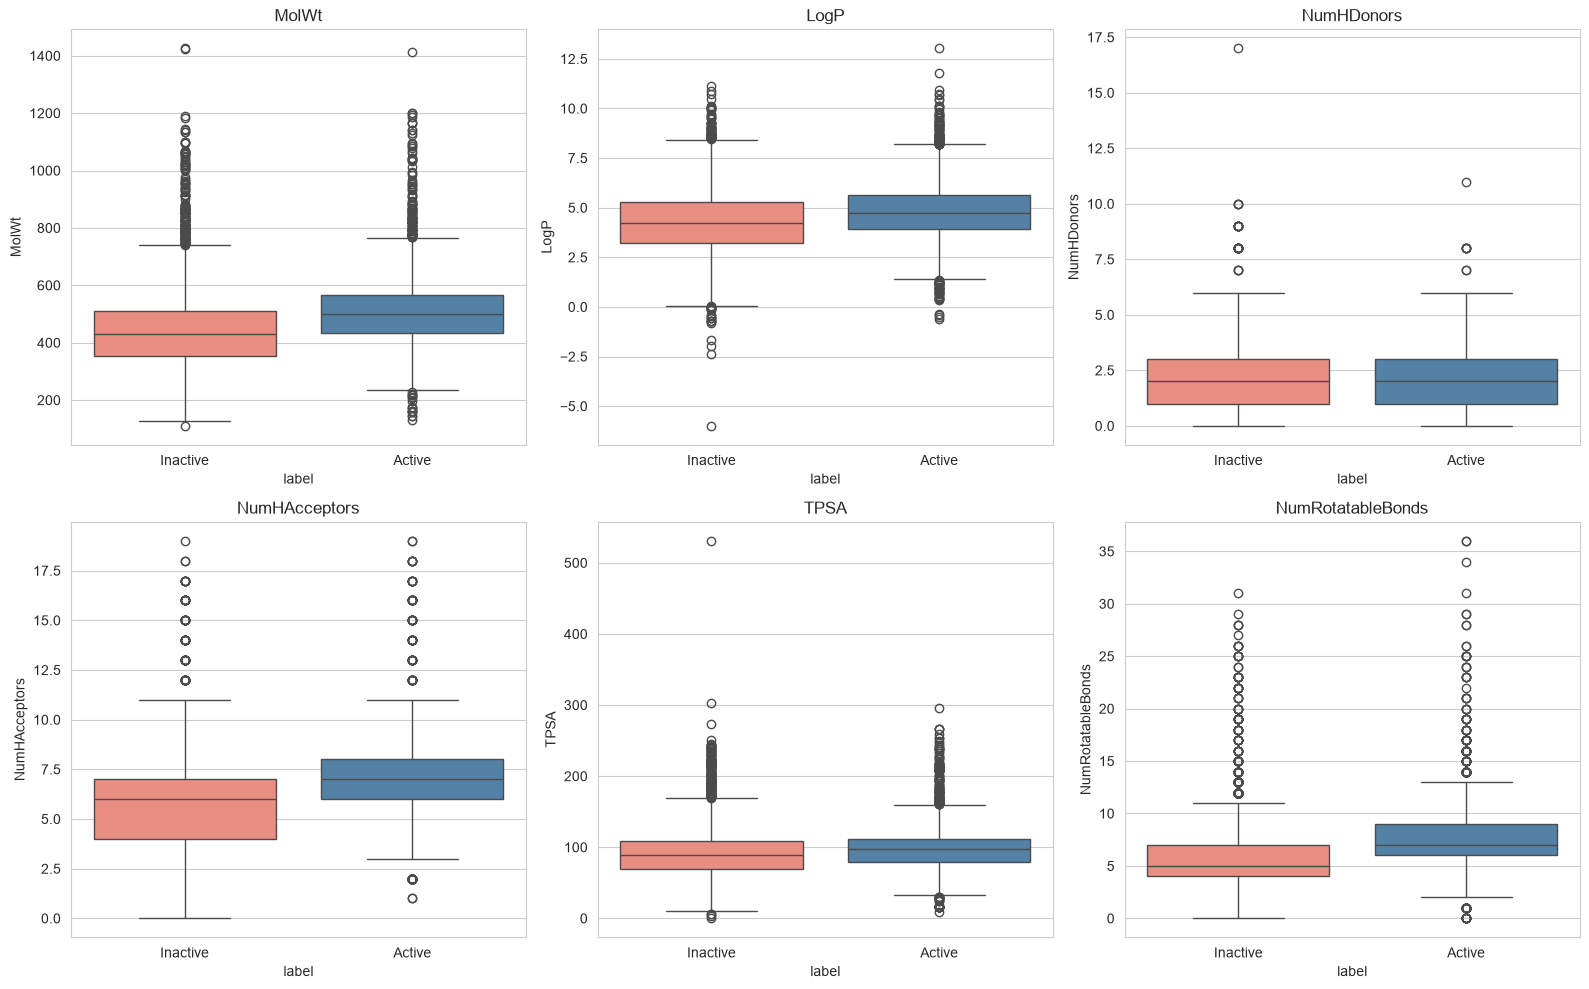

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
descriptors = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']

for ax, desc in zip(axes.flat, descriptors):
    sns.boxplot(data=df, x='label', y=desc, ax=ax, palette=['salmon', 'steelblue'])
    ax.set_xticklabels(['Inactive', 'Active'])
    ax.set_title(desc)
#checking differences beetwen active and inactive
plt.tight_layout()
plt.savefig('results/plots/descriptors_by_activity.png', dpi=150, bbox_inches='tight')
plt.show()

## Molecular Descriptors by Activity Class

Boxplots comparing key molecular descriptors (Lipinski-related)
between active and inactive EGFR compounds.

Active compounds show modestly higher molecular weight, LogP,
H-bond acceptor count, and rotatable bond count compared to inactive
compounds, while H-bond donor count and TPSA show substantial
overlap between the two classes. These differences are consistent
with known EGFR inhibitor chemotypes but are individually modest to
no single descriptor cleanly separates active from inactive
compounds, motivating the use of fingerprint-based machine learning
rather than simple descriptor thresholds for
activity prediction.

In [11]:
import pickle


np.save("data/egfr_fingerprints.npy", fingerprints)

df_to_save = df.drop(columns=['mol'])
df_to_save.to_csv("data/egfr_features_and_labels.csv", index=False)

print(f"Saved fingerprints: {fingerprints.shape}")
print(f"Saved features/labels: {df_to_save.shape}")

Saved fingerprints: (13518, 2048)
Saved features/labels: (13518, 11)


## Molecular Representation — Summary

Each molecule was converted from SMILES to Morgan fingerprints
(radius=2, 2048 bits) using RDKits updated `MorganGenerator` API,
providing a binary representation suitable for machine learning
classifiers. Six Lipinski-related molecular descriptors (molecular
weight, LogP, H-bond donors/acceptors, TPSA, rotatable bonds) were
also computed to enable both interpretability and future
drug-likeness filtering.

**Output**: 13,518 molecules, each represented by a 2048-bit Morgan
fingerprint plus 6 molecular descriptors, saved alongside their
activity labels for use in the next notebook.

This dataset is now ready for training and benchmarking classification
models (Random Forest, XGBoost) to distinguish active from inactive
EGFR inhibitors.